## Loading and plotting data from a file

First thing we need to do is to import the MassJ package.

In [1]:
using MassJ

For this first example, the mzXML file from the test folder of the package will be used. In order to dowanload the file, we need the `HTTP`package.


In [2]:
using HTTP

In [3]:
data = download("https://raw.githubusercontent.com/ajgiuliani/MassJ.jl/master/test/test.mzXML", 
                expanduser("~/Downloads/test.mzXML")) ;

Now, using the `info` function of the `MassJ`package, we will see what is inside the file

In [4]:
info(data)

4-element Vector{String}:
 "6 scans"
 "MS1+"
 "MS2+ 1255.5  CID(CE=18)"
 "MS3+ 902.33  PQD(CE=35)"

Hence, the `test.mzXML`file contains 6 scans. Among these, we find some mass spectrometry scans (`MS1`), measured in the positive ion mode (`+`). 
In addition, we have some MS/MS scans in the positive ion mode as well (`MS2+`) obtained on the m/z 1255.5 precusor under CID activation conditions and with collision energy of 18.  
The file also contains MS3 data in the positive ion measured on the m/z 902.33 precusor under PQD activation conditions with a collision energy of 35.

The data can be loaded into a variable that we can call `s`

In [5]:
s = load(data)

MSrun(6 scans, 0 chromatograms)
  file_metadata keys: —
  first scan: MSscans(num=1, MS1+, 22320 pts m/z=[140.083, 2000.0], rt=0.1384 min, tic=5.08195e6)
  last  scan: MSscans(num=6, MS3+ PQD@35.0eV, 23400 pts m/z=[50.083, 2000.0], rt=5.7689 min, tic=4.84455  precursor=902.33)


As expected, the `s` variable contains an array of 6 `MSscans`. The fields of the individual scans may be accessed using the corresponding fields. In the following, `s[1]` refers to the first element of `s` which is a Vector.  In Julia `Vector`is the same as an `Array` wwith on dimension.

In [6]:
s[1].num

1-element Vector{Int64}:
 1

In [7]:
s[1].polarity

1-element Vector{String}:
 "+"

In [8]:
s[1].level

1-element Vector{Int64}:
 1

In [9]:
s[1].basePeakMz

628.333

In [10]:
s[1].basePeakIntensity

102558.0

The `println`Julia function may be used as well:

In [11]:
println("s[1].num = $(s[1].num)")
println("s[1].polarity = $(s[1].polarity)")
println("s[1].level = $(s[1].level)")
println("s[1].basePeakMz = $(s[1].basePeakMz)")
println("s[1].basePeakIntensity = $(s[1].basePeakIntensity)")

s[1].num = [1]
s[1].polarity = ["+"]
s[1].level = [1]
s[1].basePeakMz = 628.333
s[1].basePeakIntensity = 102558.0


The mass spectrum is stored in two arrays, one containing the mass to charge ratio and the other one containing the intensities:

In [12]:
s[1].mz

22320-element Vector{Float64}:
  140.0833282470703
  140.1666717529297
  140.25
  140.3333282470703
  140.4166717529297
  140.5
  140.5833282470703
  140.6666717529297
  140.75
  140.8333282470703
  140.9166717529297
  141.0
  141.0833282470703
    ⋮
 1999.0833740234375
 1999.166748046875
 1999.25
 1999.3333740234375
 1999.416748046875
 1999.5
 1999.5833740234375
 1999.666748046875
 1999.75
 1999.8333740234375
 1999.916748046875
 2000.0

In [13]:
s[1].int

22320-element Vector{Float64}:
 236.31689453125
  83.14080810546875
   9.520808219909668
   0.0
   0.0
   0.0
   0.0
  30.42954444885254
  83.86954498291016
 321.0277099609375
 719.3600463867188
 719.0527954101562
 498.6211853027344
   ⋮
   0.0
   0.002726171864196658
   0.0008099044789560139
   6.637149635935202e-5
   0.0
   0.0
   0.0
   1.9453743504982413e-7
   1.1345706241172593e-7
   1.900308177482657e-8
   0.0
   0.0

We also need to a package to plot. We will use the `Plots` package using the default backend.

In [14]:
using Plots

We can plot this mass spectrum using the `Plots` package.

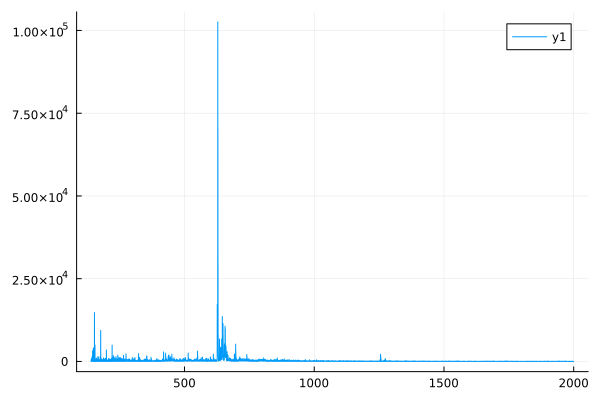

In [15]:
plot(s[1].mz, s[1].int)

We use a recepie for plotting MSscans:

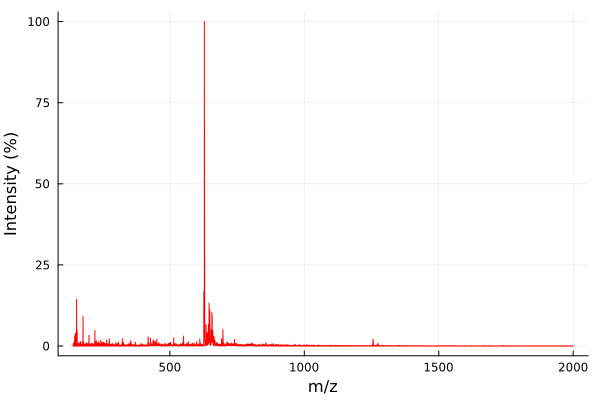

In [16]:
plot(s[1])

The previous graph is plotted in relative intensity. Absolute intensities are plotted by specifying the `:absolute` keyword:

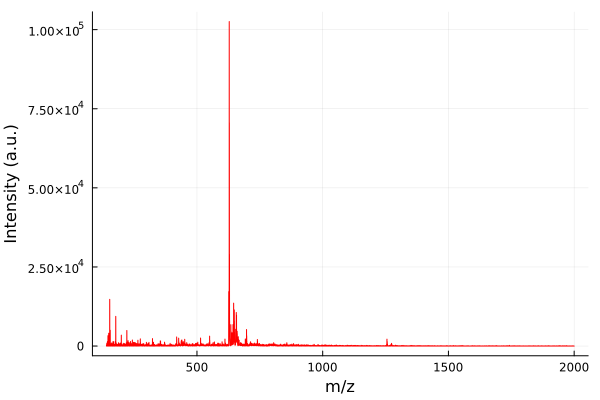

In [17]:
plot(s[1], method = :absolute)

In [18]:
plotly()

┌ Warning: Failed to load integration with PlotlyBase & PlotlyKaleido.
│   exception =
│    ArgumentError: Package PlotlyBase not found in current path.
│    - Run `import Pkg; Pkg.add("PlotlyBase")` to install the PlotlyBase package.
│    Stacktrace:
│      [1] macro expansion
│        @ ./loading.jl:2405 [inlined]
│      [2] macro expansion
│        @ ./lock.jl:376 [inlined]
│      [3] __require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:2388
│      [4] require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:2364
│      [5] top-level scope
│        @ ~/.julia/packages/Plots/GIume/src/backends.jl:581
│      [6] eval(m::Module, e::Any)
│        @ Core ./boot.jl:489
│      [7] _initialize_backend(pkg::Plots.PlotlyBackend)
│        @ Plots ~/.julia/packages/Plots/GIume/src/backends.jl:580
│      [8] backend(pkg::Plots.PlotlyBackend)
│        @ Plots ~/.julia/packages/Plots/GIume/src/backends.jl:256
│      [9] plotly()
│        @ Plots ~/.julia/packages/Plots/GIume/sr

Plots.PlotlyBackend()

Note the interactivity provided by the Plotly backend

In [19]:
plot(s[1])